In [1]:
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

### Combining historical data with daily reports

In [2]:
historical_df = pd.read_json('isw_historical_data.json')

In [3]:
DAILY_DIR = 'isw_data' 
daily_data_list = []

In [4]:
for filepath in glob.glob(f"{DAILY_DIR}/*"):
    with open(filepath, 'r', encoding='utf-8') as f:
        try:
            daily_json = json.load(f)
            daily_data_list.append(daily_json)
        except:
            text = f.read()
            filename = os.path.basename(filepath)
            daily_data_list.append({'date': filename, 'text': text})

In [5]:
daily_df = pd.DataFrame(daily_data_list)
isw_df = pd.concat([historical_df, daily_df], ignore_index=True)

In [6]:
isw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1121 entries, 0 to 1120
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1121 non-null   object
 1   url     1121 non-null   str   
 2   text    1121 non-null   str   
dtypes: object(1), str(2)
memory usage: 26.4+ KB


### Data prep & feature engineering

In [7]:
isw_df['date'] = pd.to_datetime(isw_df['date'])
isw_df = isw_df.sort_values('date').reset_index(drop=True)

In [8]:
isw_df['word_count'] = isw_df['text'].apply(lambda x: len(str(x).split()))

In [9]:
isw_df['word_count_7d_avg'] = isw_df['word_count'].rolling(window=7).mean()

In [10]:
domain_stop_words = {
    'russian', 'ukrainian', 'forces', 'military', 'oblast', 'russia', 'ukraine',
    'likely', 'reported', 'said', 'isw', 'troops', 'war', 'claimed', 'stated',
    'defense', 'attack', 'attacks', 'region', 'city', 'area', 'continue', 'continued',
    'direction', 'positions', 'personnel', 'operations', 'combat', 'staff', 'general',
    'ministry', 'federation', 'unit', 'units', 'command', 'support', 'equipment',
    'provided', 'including', 'new', 'used', 'state', 'did', 'just', 'time', 'day', 'today', 'https',
    'com', 'near', 'www', 'ua', '2025', 'org', 'dot', 'facebook', 'posts', 'generalstaff', 'generalstaffzsu'
}

In [11]:
final_stop_words = list(set(ENGLISH_STOP_WORDS) | domain_stop_words)

In [12]:
tfidf_vectorizer = TfidfVectorizer(stop_words=final_stop_words, max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(isw_df['text'])

In [13]:
words = tfidf_vectorizer.get_feature_names_out()
avg_tfidf_scores = tfidf_matrix.mean(axis=0).A1

In [14]:
top_words_df = pd.DataFrame({'Word': words, 'TFIDF_Score': avg_tfidf_scores})
top_words_df = top_words_df.sort_values(by='TFIDF_Score', ascending=False).head(20)

In [15]:
keywords = [
    'bakhmut', 'kherson', 'avdiivka',                 
    'drone', 'counteroffensive', 'artillery', 'missile'
]
for word in keywords:
    isw_df[f'{word}_count'] = isw_df['text'].str.lower().str.count(word)
    isw_df[f'{word}_trend'] = isw_df[f'{word}_count'].rolling(window=14).mean()

### Visualisations

In [16]:
sns.set_theme(style="whitegrid", font_scale=1.3)

#### Viz 1: Report Word Count Over Time

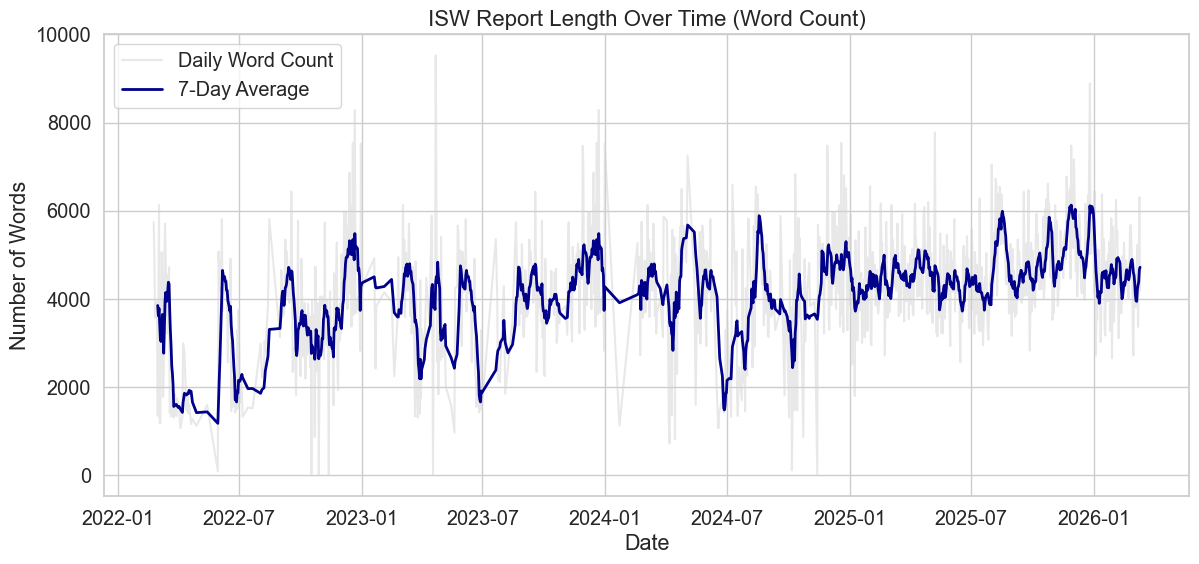

In [17]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=isw_df, x='date', y='word_count', color='lightgray', alpha=0.5, label='Daily Word Count')
sns.lineplot(data=isw_df, x='date', y='word_count_7d_avg', color='darkblue', linewidth=2, label='7-Day Average')
plt.title('ISW Report Length Over Time (Word Count)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Words')
plt.legend()
plt.show()

#### Viz 2: Top 20 Sensible Words

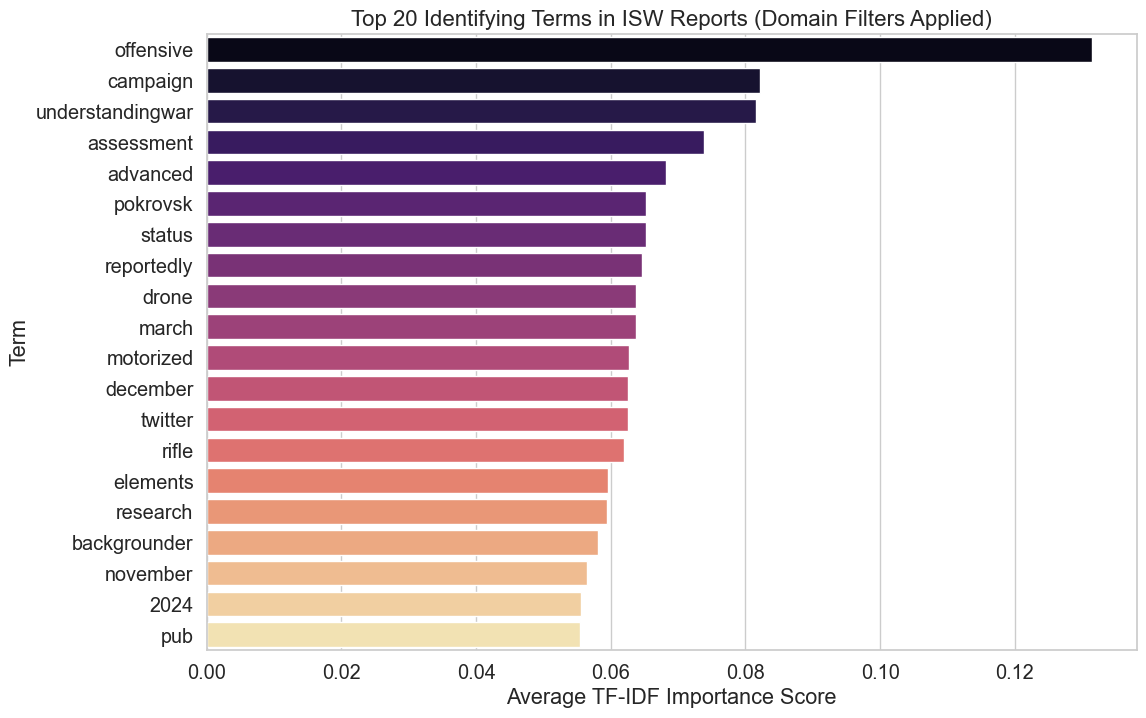

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_words_df, x='TFIDF_Score', y='Word', palette='magma', hue='Word', legend=False)
plt.title('Top 20 Identifying Terms in ISW Reports (Domain Filters Applied)', fontsize=16)
plt.xlabel('Average TF-IDF Importance Score')
plt.ylabel('Term')
plt.show()

#### Viz 3: Battlegrounds Over Time

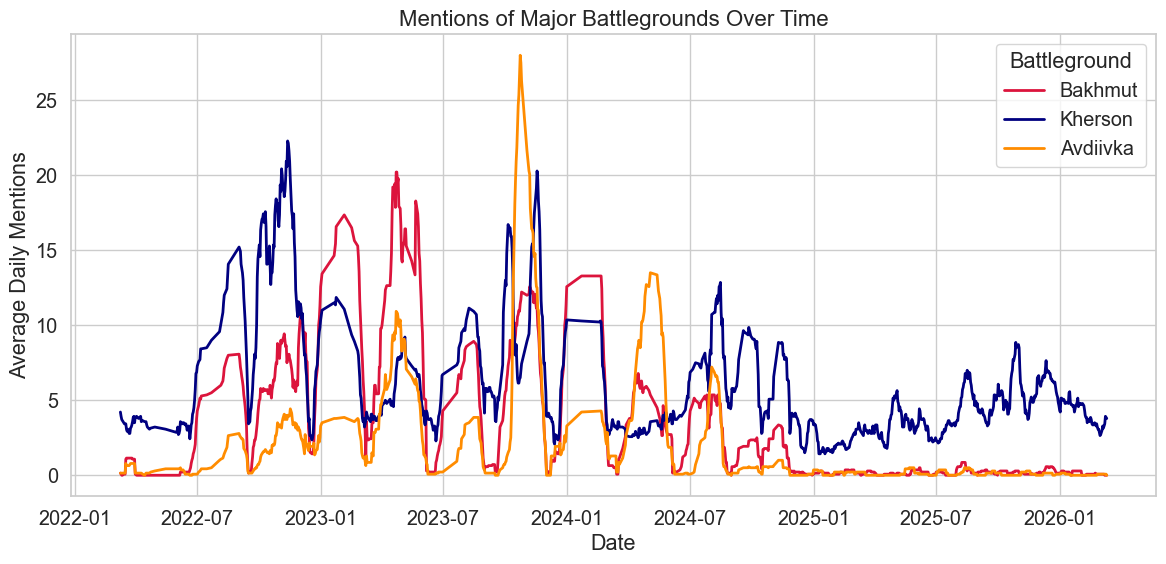

In [19]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=isw_df, x='date', y='bakhmut_trend', label='Bakhmut', color='crimson', linewidth=2)
sns.lineplot(data=isw_df, x='date', y='kherson_trend', label='Kherson', color='navy', linewidth=2)
sns.lineplot(data=isw_df, x='date', y='avdiivka_trend', label='Avdiivka', color='darkorange', linewidth=2)
plt.title('Mentions of Major Battlegrounds Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Daily Mentions')
plt.legend(title='Battleground')
plt.show()

#### Viz 4: Tech & Tactics Over Time

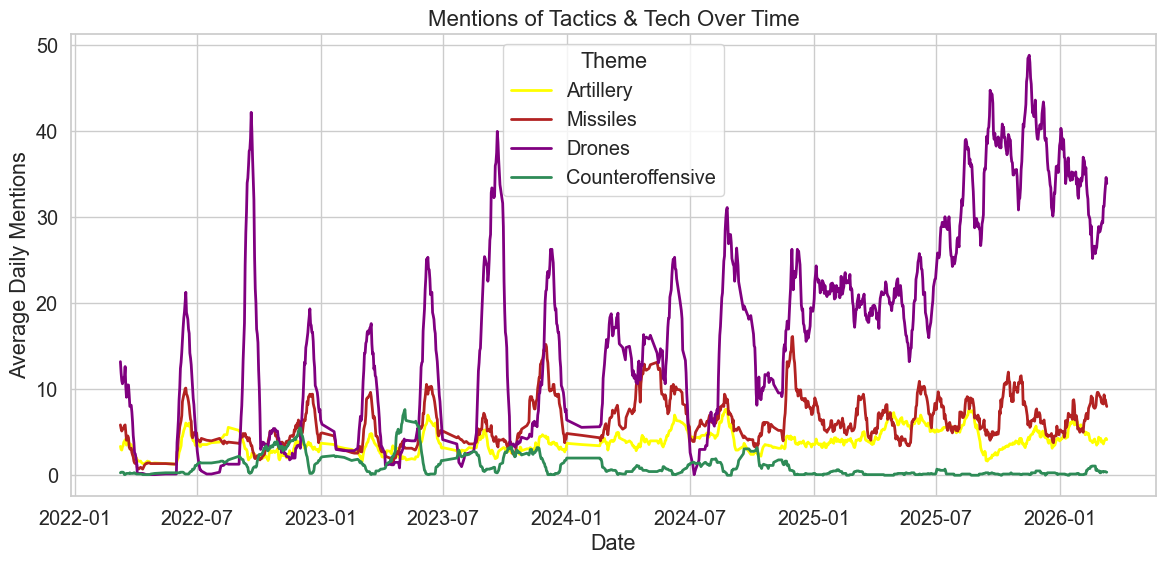

In [20]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=isw_df, x='date', y='artillery_trend', label='Artillery', color='yellow', linewidth=2)
sns.lineplot(data=isw_df, x='date', y='missile_trend', label='Missiles', color='firebrick', linewidth=2)
sns.lineplot(data=isw_df, x='date', y='drone_trend', label='Drones', color='purple', linewidth=2)
sns.lineplot(data=isw_df, x='date', y='counteroffensive_trend', label='Counteroffensive', color='seagreen', linewidth=2)
plt.title('Mentions of Tactics & Tech Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Daily Mentions')
plt.legend(title='Theme')
plt.show()